In [3]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches
from scipy.integrate import simpson  
from joblib import Parallel, delayed
import matplotlib.cm as cm
import matplotlib.colors as colors

In [ ]:
#function
def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL

def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    #check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    #max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):

    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)


    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
 
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < xshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T

    A_DD = np.block(A_DD)

    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r, Sigma_R, Sigma_L

def Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):
    N = xshumu
    
    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL 的维度是 160x160
    return G_RL, Sigma_R, Sigma_L

def calc_T_eff(Bz_val, E_val):
    # 1. 动态更新层间跃迁矩阵
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz_val)
    
    # 2. 计算格林函数 (传入全局组装好的不均匀 Sigma_virtual_big)
    G_all, Sigma_R, Sigma_L = Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E_val, Sigma_virtual_big, eta=1e-6)
    
    d_device = Sigma_L.shape[0] 
    
    # 3. 提取非零小矩阵块
    slices = []
    small_gammas = []
    
    # --- 左极 ---
    gamma_L_small = 1j * (Sigma_L - Sigma_L.conj().T)
    slices.append((0, d_device))
    small_gammas.append(gamma_L_small)
    
    # --- 虚拟探针 (核心修改：从 T_d_list 中按位置读取特定的展宽) ---
    for i in range(total_sites):
        slices.append((2 * i, 2 * i + 2))
        small_gammas.append(T_d_list[i])
        
    # --- 右极 ---
    gamma_R_small = 1j * (Sigma_R - Sigma_R.conj().T)
    slices.append((M - d_device, M))
    small_gammas.append(gamma_R_small)
    
    num_probes = len(slices)
    
    # 4. 极速计算透射矩阵 T_ij
    T_matrix = np.zeros((num_probes, num_probes), dtype=float)
    for i in range(num_probes):
        start_i, end_i = slices[i]
        gamma_i = small_gammas[i]
        for j in range(num_probes):
            if i == j: continue 
            start_j, end_j = slices[j]
            gamma_j = small_gammas[j]
            
            G_ij = G_all[start_i:end_i, start_j:end_j]
            Ga_ji = G_ij.conj().T
            T_matrix[i, j] = np.real(np.trace(gamma_i @ G_ij @ gamma_j @ Ga_ji))

    # 5. 解 Büttiker 虚拟电压方程
    V_L = 1.0
    V_R = 0.0
    W = np.zeros((total_sites, total_sites), dtype=float)
    B_vec = np.zeros(total_sites, dtype=float)
    
    for p in range(1, total_sites + 1):  
        row = p - 1  
        W[row, row] = np.sum(T_matrix[p, :])
        for q in range(1, total_sites + 1):
            if p != q:
                col = q - 1
                W[row, col] = -T_matrix[p, q]
        B_vec[row] = T_matrix[p, 0] * V_L + T_matrix[p, num_probes - 1] * V_R

    V_virtual = np.linalg.solve(W, B_vec)

    # 6. 整合有效电导 T_eff
    T_eff = T_matrix[0, num_probes - 1] * (V_L - V_R) 
    for v in range(1, total_sites + 1):
        T_eff += T_matrix[0, v] * (V_L - V_virtual[v - 1])
        
    return T_eff

def Gr_DD_xuni(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, Sigma_virtual_big, eta=1e-6):

    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < xshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T

    A_DD = np.block(A_DD)

    # ==========================================
    # 核心修改：在求逆前，减去虚拟探针的退相干自能矩阵
    # ==========================================
    A_DD = A_DD - Sigma_virtual_big

    # 对全矩阵求逆，得到包含退相干效应的总推迟格林函数
    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r, Sigma_R, Sigma_L

def calc_T_eff_single(E_val, mats, xshumu, T_d_list, Sigma_virtual_big, eta=1e-6):
    # 提取当前通道的矩阵
    H_q_list = mats["H_q_list"]
    T_21 = mats["T_21"]
    H_l = mats["H_l"]
    T_l = mats["T_l"]
    H_r = mats["H_r"]
    T_r = mats["T_r"]
    T_LD = mats["T_LD"]
    T_RD = mats["T_RD"]

    # 调用包含虚拟自能的全矩阵求解器
    G_all, Sigma_R, Sigma_L = Gr_DD_xuni(
        H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, 
        xshumu, E_val, Sigma_virtual_big, eta=eta
    )
    
    d_device = Sigma_L.shape[0]  
    M = xshumu * d_device        
    
    slices = []
    small_gammas = []
    
    # --- 左极 ---
    gamma_L_small = 1j * (Sigma_L - Sigma_L.conj().T)
    slices.append((0, d_device))
    small_gammas.append(gamma_L_small)
    
    # --- 虚拟探针 ---
    for i in range(xshumu):
        slices.append((d_device * i, d_device * i + d_device))
        small_gammas.append(T_d_list[i])
        
    # --- 右极 ---
    gamma_R_small = 1j * (Sigma_R - Sigma_R.conj().T)
    slices.append((M - d_device, M))
    small_gammas.append(gamma_R_small)
    
    num_probes = len(slices) 
    
    # 计算多端透射矩阵 T_ij
    T_matrix = np.zeros((num_probes, num_probes), dtype=float)
    for i in range(num_probes):
        start_i, end_i = slices[i]
        gamma_i = small_gammas[i]
        for j in range(num_probes):
            if i == j: continue 
            start_j, end_j = slices[j]
            gamma_j = small_gammas[j]
            
            G_ij = G_all[start_i:end_i, start_j:end_j]
            Ga_ji = G_ij.conj().T
            T_matrix[i, j] = np.real(np.trace(gamma_i @ G_ij @ gamma_j @ Ga_ji))

    # 解 Büttiker 虚拟探针的电压方程
    V_L = 1.0
    V_R = 0.0
    
    W = np.zeros((xshumu, xshumu), dtype=float)
    B_vec = np.zeros(xshumu, dtype=float)
    
    for p in range(1, xshumu + 1):  
        row = p - 1  
        W[row, row] = np.sum(T_matrix[p, :]) - T_matrix[p, p]
        
        for q in range(1, xshumu + 1):
            if p != q:
                col = q - 1
                W[row, col] = -T_matrix[p, q]
                
        B_vec[row] = T_matrix[p, 0] * V_L + T_matrix[p, num_probes - 1] * V_R

    V_virtual = np.linalg.solve(W, B_vec)

    # 计算有效电导 T_eff
    T_eff = T_matrix[0, num_probes - 1] * (V_L - V_R) 
    for v in range(1, xshumu + 1):
        T_eff += T_matrix[0, v] * (V_L - V_virtual[v - 1])
        
    return T_eff

def calc_G_total_at_E(E_val, matrix_dict, xshumu, T_d_list, Sigma_virtual_big, eta=1e-6):
    G_total_at_E = 0.0
    for dhs, mats in matrix_dict.items():
        G_single_channel = calc_T_eff_single(E_val, mats, xshumu, T_d_list, Sigma_virtual_big, eta)
        G_total_at_E += G_single_channel
        
    return G_total_at_E

def calc_G_total_at_E_1(E_val, matrix_dict, xshumu, eta):
    """
    计算给定单一能量点 E_val 下，所有 transverse modes 的总电导
    """
    G_total_at_E = 0.0  
    
    # 遍历字典中所有的横向模式
    for dhs, mats in matrix_dict.items():
        G_RL, Sigma_R, Sigma_L = Gr_DD_2(
            H_q_list=mats["H_q_list"],
            H_l=mats["H_l"],
            H_r=mats["H_r"],
            T_21=mats["T_21"],
            T_LD=mats["T_LD"],
            T_l=mats["T_l"],
            T_RD=mats["T_RD"],
            T_r=mats["T_r"],
            xshumu=xshumu, 
            E=E_val,
            eta=eta
        )
        
        # 计算左右电极的展宽矩阵
        zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
        zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)
        
        # 计算当前模式的透射率并累加
        G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
        G_total_at_E += np.real(G_complex)
        
    return G_total_at_E
    


In [21]:
#中间矩阵信息  锯齿形纳米管ky量子化，周长2b*m
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onstie(u, t):
    return -t*sx+u+(u)*s0

def H_hop(t,ky,b):
    return -2*t*np.cos(ky*b)*np.array([[0, 1], [0, 0]], complex)

mu_q=0
mu_r=0
mu_l=0
t=3

a=1
b=3**(0.5)/2*a

m=33

xshumu=20 # 可变
#不同ky
max_duihaoshu = int(2 * m / 3)

matrix_dict = {}

for duihaoshu in range(0,max_duihaoshu + 1):  # +1 是为了包含 2*m/3 这个值本身
    
    # 根据当前的 duihaoshu 计算 ky
    ky = 2 * np.pi / 3 *    3 * duihaoshu / (b * 2 * m)
    
    # 1. 中心区器件矩阵
    H_q = H_onstie(mu_q, t)
    T_21 = H_hop(t, ky, b)
    
    # 建立中心区各层的列表 (使用列表推导式更简洁)
    H_q_list = [H_q for _ in range(xshumu)]
    
    # 2. 左右电极及耦合矩阵
    H_l = H_onstie(mu_l, t)
    T_l = H_hop(t, ky, b).conj().T
    
    H_r = H_onstie(mu_r, t)
    T_r = H_hop(t, ky, b)
    
    T_LD = H_hop(t, ky, b)*0.94
    T_RD = H_hop(t, ky, b).conj().T*0.94


    # 3. 将这一组参数打包存入字典
    matrix_dict[duihaoshu] = {
        "H_q_list": H_q_list,
        "T_21": T_21,
        "H_l": H_l,
        "T_l": T_l,
        "H_r": H_r,
        "T_r": T_r,
        "T_LD": T_LD,
        "T_RD": T_RD
    }




C:\Users\taoji\AppData\Local\Temp\ipykernel_13148\839991228.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


Calculating Lead bands: 100%|██████████| 23/23 [00:00<00:00, 24.51it/s]


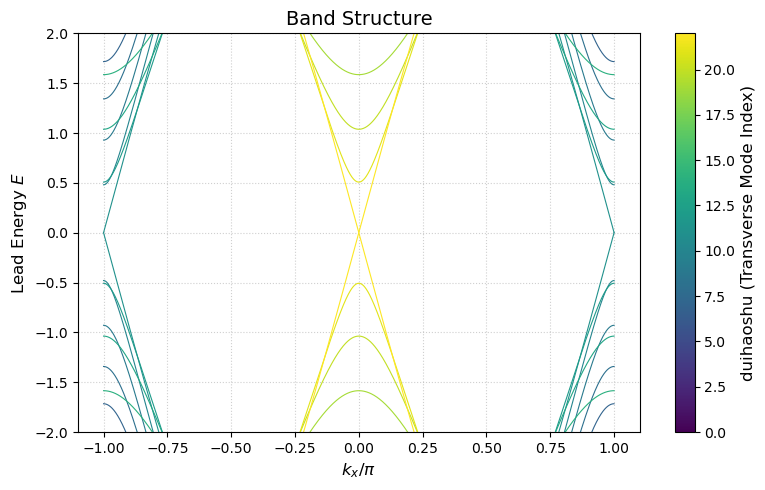

In [6]:
#ky(多个ky)画左边能带
# 定义 k 区间
ks1 = np.linspace(-1*np.pi, 1*np.pi, 5001)

def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

plt.figure(figsize=(8, 5)) # 保持宽比例，给 Colorbar 留位置

# ================= 设置色图 (Colormap) =================
cmap = cm.get_cmap('viridis')
# norm 将 duihaoshu 的范围 (0 到 max_duihaoshu) 映射到 0~1 的颜色空间
norm = colors.Normalize(vmin=0, vmax=max_duihaoshu)

# 遍历字典里的所有 duihaoshu 模式
for dhs, mats in tqdm(matrix_dict.items(), desc="Calculating Lead bands"):
    
    
    H_q = mats["H_q_list"][0] 
    T_21 = mats["T_21"]
    # ==========================================
    
    energies1 = []
    # 计算当前电极模式的能带
    for k in ks1:

        H_k = Hk(k, H_q, T_21)
        evals1 = np.linalg.eigvalsh(H_k)
        energies1.append(evals1)
        
    energies1 = np.array(energies1)
    
    # 获取当前 duihaoshu 对应的颜色
    color = cmap(norm(dhs))
    
    # 画出当前电极模式的能带
    for i in range(energies1.shape[1]):
        # 使用 plot 画线，linewidth=0.8 既不会太细也不会互相粘连
        plt.plot(ks1/np.pi, energies1[:, i], color=color, linewidth=0.8)

# ================= 设置坐标轴和颜色条 =================
plt.xlabel(r'$k_x/\pi$', fontsize=12)
plt.ylabel('Lead Energy $E$', fontsize=12)
plt.title('Band Structure', fontsize=14) # 改了标题
plt.grid(True, linestyle=':', alpha=0.6)

# 添加右侧颜色条
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('duihaoshu (Transverse Mode Index)', fontsize=12)
plt.ylim(-2, 2)
plt.tight_layout()
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_13148\2291654788.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')
Calculating Lead bands: 100%|██████████| 23/23 [00:00<00:00, 24.26it/s]


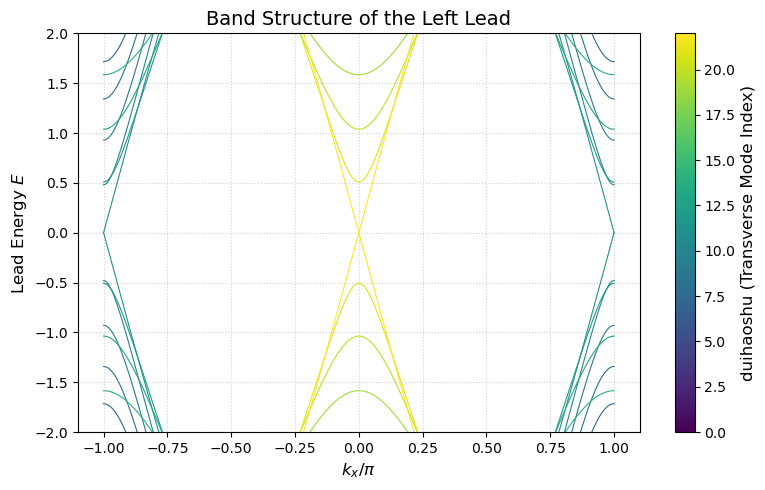

In [7]:
#ky(多个ky)画左边能带
# 定义 k 区间
ks1 = np.linspace(-1*np.pi, 1*np.pi, 5001)

def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

plt.figure(figsize=(8, 5)) # 保持宽比例，给 Colorbar 留位置

# ================= 设置色图 (Colormap) =================
cmap = cm.get_cmap('viridis')
# norm 将 duihaoshu 的范围 (0 到 max_duihaoshu) 映射到 0~1 的颜色空间
norm = colors.Normalize(vmin=0, vmax=max_duihaoshu)

# 遍历字典里的所有 duihaoshu 模式
for dhs, mats in tqdm(matrix_dict.items(), desc="Calculating Lead bands"):
    
    # ================= 核心修改 =================
    # 提取当前 duihaoshu 对应的【左电极】哈密顿量和跃迁矩阵
    H_l = mats["H_l"] 
    T_l = mats["T_l"]
    # ==========================================
    
    energies1 = []
    # 计算当前电极模式的能带
    for k in ks1:
        # 传入电极的 H_l 和 T_l
        H_k = Hk(k, H_l, T_l)
        evals1 = np.linalg.eigvalsh(H_k)
        energies1.append(evals1)
        
    energies1 = np.array(energies1)
    
    # 获取当前 duihaoshu 对应的颜色
    color = cmap(norm(dhs))
    
    # 画出当前电极模式的能带
    for i in range(energies1.shape[1]):
        # 使用 plot 画线，linewidth=0.8 既不会太细也不会互相粘连
        plt.plot(ks1/np.pi, energies1[:, i], color=color, linewidth=0.8)

# ================= 设置坐标轴和颜色条 =================
plt.xlabel(r'$k_x/\pi$', fontsize=12)
plt.ylabel('Lead Energy $E$', fontsize=12)
plt.title('Band Structure of the Left Lead', fontsize=14) # 改了标题
plt.grid(True, linestyle=':', alpha=0.6)

# 添加右侧颜色条
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('duihaoshu (Transverse Mode Index)', fontsize=12)
plt.ylim(-2, 2)
plt.tight_layout()
plt.show()

开始并行计算，总共 1000 个能量点，启动 14 个线程...


Calculating Total Conductance: 100%|██████████| 1000/1000 [00:01<00:00, 725.24it/s]


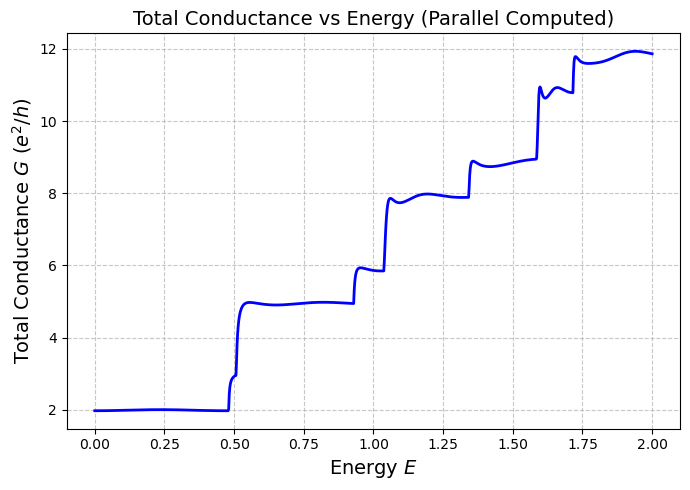

In [22]:
# G vs E xshumu定

# ================= 2. 参数设置与并行计算 =================
# 设置能量范围：从 -0.5 到 0.5，共 100 个点
E_vals = np.linspace(0, 2, 1000)
eta = 1e-6

print(f"开始并行计算，总共 {len(E_vals)} 个能量点，启动 14 个线程...")

# 核心：使用 joblib 开启 14 个进程进行并行计算
# tqdm 用于在主进程中显示分配进度
G_total_list = Parallel(n_jobs=14)(
    delayed(calc_G_total_at_E_1)(E_val, matrix_dict, xshumu, eta) 
    for E_val in tqdm(E_vals, desc="Calculating Total Conductance")
)

# 将返回的列表转换为 numpy 数组以便画图
G_total_list = np.array(G_total_list)

# ================= 3. 画出物理图像 =================
plt.figure(figsize=(7, 5))

# 画线，使用稍粗的线条
plt.plot(E_vals, G_total_list, color='b', linewidth=2)

plt.xlabel(r'Energy $E$', fontsize=14)
plt.ylabel(r'Total Conductance $G \ (e^2/h)$', fontsize=14)
plt.title('Total Conductance vs Energy (Parallel Computed)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
#plt.ylim(0,10)

plt.show()

虚拟探针空间分布矩阵初始化完成！
启动 14 线程并行计算 G vs E (引入退相干效应)...


Calculating Dephasing G: 100%|██████████| 1000/1000 [00:14<00:00, 68.50it/s]


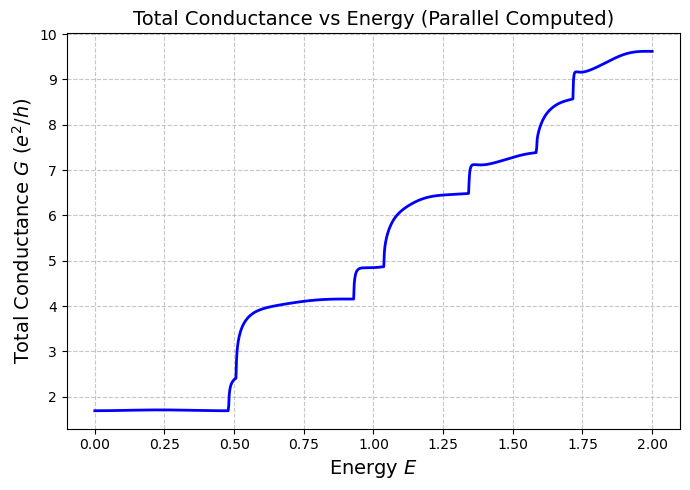

In [27]:
total_sites = xshumu 

# ================= 3. 核心修改：虚拟探针退相干初始化 =================
M = total_sites * 2  
base_T_d = 0.05* np.array([[1, 0], [0, 1]], dtype=complex)
T_d_list = []
xushuzineng_list = []

for i in range(total_sites):
    # ---------------------------------------------------------
    # 未来可以在这里写 if/else 逻辑来区分边缘和体态的退相干！
    # ---------------------------------------------------------
    current_T_d = base_T_d.copy()  
    
    T_d_list.append(current_T_d)
    xushuzineng_list.append(-1j * current_T_d / 2)

# 手动分块组装大自能矩阵
Sigma_virtual_big = np.zeros((M, M), dtype=complex)
for i in range(total_sites):
    start_idx = 2 * i
    end_idx = 2 * i + 2
    Sigma_virtual_big[start_idx:end_idx, start_idx:end_idx] = xushuzineng_list[i]

print("虚拟探针空间分布矩阵初始化完成！")

# ================= 4. 并行扫描能量 E 并画图 =================
# 设定扫描区间为 0 到 2，共 100 个点
E_vals = np.linspace(0, 2, 1000)
eta = 1e-6

print(f"启动 14 线程并行计算 G vs E (引入退相干效应)...")

# 调用多线程与总电导求解函数
G_total_list = Parallel(n_jobs=14)(
    delayed(calc_G_total_at_E)(E_val, matrix_dict, xshumu, T_d_list, Sigma_virtual_big, eta)
    for E_val in tqdm(E_vals, desc="Calculating Dephasing G")
)

G_total_list = np.array(G_total_list)

# ================= 3. 画出物理图像 =================
plt.figure(figsize=(7, 5))

# 画线，使用稍粗的线条
plt.plot(E_vals, G_total_list, color='b', linewidth=2)

plt.xlabel(r'Energy $E$', fontsize=14)
plt.ylabel(r'Total Conductance $G \ (e^2/h)$', fontsize=14)
plt.title('Total Conductance vs Energy (Parallel Computed)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
#plt.ylim(0,10)

plt.show()

基础模式字典生成完毕！
启动 14 线程并行计算 G vs xshumu (带退相干 T_d=1e-06)...


Scanning xshumu (Dephasing): 100%|██████████| 56/56 [00:00<00:00, 201.61it/s]


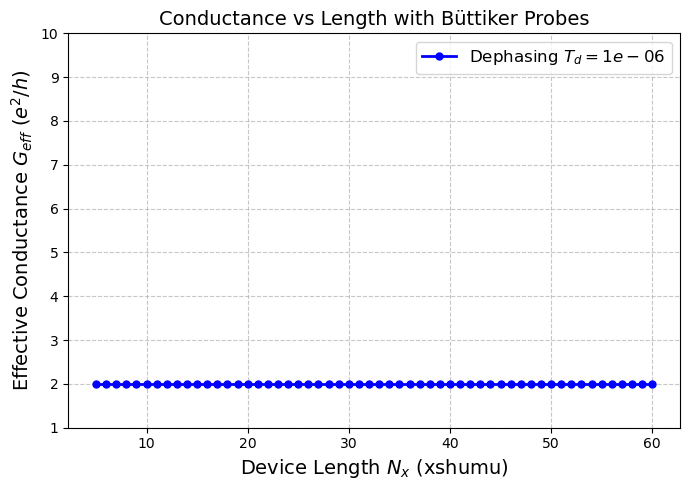

In [10]:
# ================= 2. 构建基础模式字典 (不再固定 xshumu) =================
max_duihaoshu = int(2 * m / 3)
matrix_dict_base = {}

for duihaoshu in range(0, max_duihaoshu + 1):  
    ky = 2 * np.pi / 3 * 3 * duihaoshu / (b * 2 * m)
    
    H_q = H_onstie(mu_q, t)
    T_21 = H_hop(t, ky, b)
    H_l = H_onstie(mu_l, t)
    T_l = H_hop(t, ky, b).conj().T
    H_r = H_onstie(mu_r, t)
    T_r = H_hop(t, ky, b)
    T_LD = H_hop(t, ky, b)
    T_RD = H_hop(t, ky, b).conj().T

    # 字典中只存基础层矩阵 H_q，不再存列表
    matrix_dict_base[duihaoshu] = {
        "H_q": H_q, "T_21": T_21,
        "H_l": H_l, "T_l": T_l,
        "H_r": H_r, "T_r": T_r,
        "T_LD": T_LD, "T_RD": T_RD
    }

print(f"基础模式字典生成完毕！")

# ================= 3. 封装针对长度扫描的单点并行计算函数 =================
def compute_for_single_xshumu_dephasing(current_xshumu, base_T_d_val):
    """
    针对当前长度 current_xshumu，动态生成虚拟探针和哈密顿量列表，并计算退相干总电导
    """
    E_fixed = 0
    eta = 1e-6
    
    # --- A. 动态生成当前长度的虚拟探针自能矩阵 ---
    M = current_xshumu * 2  
    T_d_list = []
    xushuzineng_list = []

    for i in range(current_xshumu):
        current_T_d = base_T_d_val * np.array([[1, 0], [0, 1]], dtype=complex)
        T_d_list.append(current_T_d)
        xushuzineng_list.append(-1j * current_T_d / 2)

    Sigma_virtual_big = np.zeros((M, M), dtype=complex)
    for i in range(current_xshumu):
        start_idx = 2 * i
        end_idx = 2 * i + 2
        Sigma_virtual_big[start_idx:end_idx, start_idx:end_idx] = xushuzineng_list[i]
        
    # --- B. 循环计算所有通道的总有效电导 ---
    G_total_at_x = 0.0
    
    for dhs, mats in matrix_dict_base.items():
        # 动态生成特定长度的 H_q_list
        H_q_list_dynamic = [mats["H_q"] for _ in range(current_xshumu)]
        
        # 组装临时字典传入你的核心计算函数 calc_T_eff_single
        mats_dynamic = {
            "H_q_list": H_q_list_dynamic,
            "T_21": mats["T_21"],
            "H_l": mats["H_l"],
            "T_l": mats["T_l"],
            "H_r": mats["H_r"],
            "T_r": mats["T_r"],
            "T_LD": mats["T_LD"],
            "T_RD": mats["T_RD"]
        }
        
        # 调用核心退相干求解器
        G_single_channel = calc_T_eff_single(E_fixed, mats_dynamic, current_xshumu, T_d_list, Sigma_virtual_big, eta)
        G_total_at_x += G_single_channel
        
    return G_total_at_x

# ================= 4. 参数设置与并行计算 =================
# 扫描的长度范围
xshumu_vals = np.arange(5, 61)
# 基础退相干强度标量
base_T_d_scalar = 1e-6

print(f"启动 14 线程并行计算 G vs xshumu (带退相干 T_d={base_T_d_scalar})...")

G_total_list = Parallel(n_jobs=14)(
    delayed(compute_for_single_xshumu_dephasing)(int(x), base_T_d_scalar) 
    for x in tqdm(xshumu_vals, desc="Scanning xshumu (Dephasing)")
)

G_total_list = np.array(G_total_list)

# ================= 5. 绘制物理图像 =================
plt.figure(figsize=(7, 5))

# 画出带有标记点的退相干电导曲线
plt.plot(xshumu_vals, G_total_list, 'bo-', linewidth=2, markersize=5, 
         label=f'Dephasing $T_d = {base_T_d_scalar}$')

plt.xlabel(r'Device Length $N_x$ (xshumu)', fontsize=14)
plt.ylabel(r'Effective Conductance $G_{eff} \ (e^2/h)$', fontsize=14)
plt.title('Conductance vs Length with Büttiker Probes', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.ylim(1,10)
plt.tight_layout()

plt.show()

基础模式字典生成完毕！
启动 14 线程并行计算 G vs xshumu (带退相干 T_d=0.05)...


Scanning xshumu (Dephasing): 100%|██████████| 56/56 [00:00<00:00, 213.74it/s]


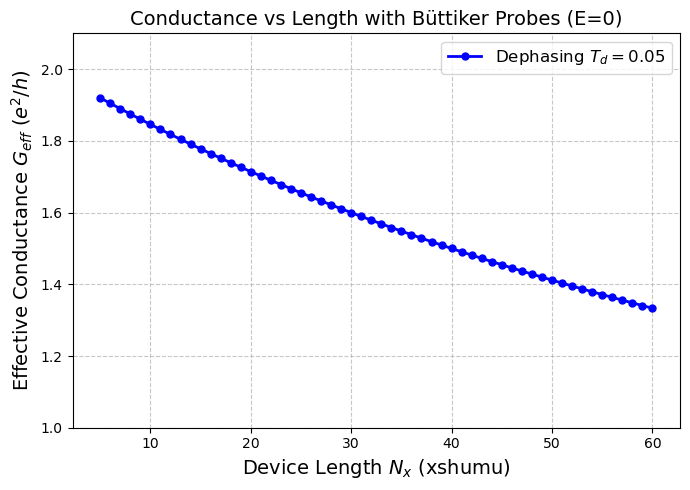

In [11]:
# ================= 2. 构建基础模式字典 (不再固定 xshumu) =================
max_duihaoshu = int(2 * m / 3)
matrix_dict_base = {}

for duihaoshu in range(0, max_duihaoshu + 1):  
    ky = 2 * np.pi / 3 * 3 * duihaoshu / (b * 2 * m)
    
    H_q = H_onstie(mu_q, t)
    T_21 = H_hop(t, ky, b)
    H_l = H_onstie(mu_l, t)
    T_l = H_hop(t, ky, b).conj().T
    H_r = H_onstie(mu_r, t)
    T_r = H_hop(t, ky, b)
    T_LD = H_hop(t, ky, b)
    T_RD = H_hop(t, ky, b).conj().T

    # 字典中只存基础层矩阵 H_q，不再存列表
    matrix_dict_base[duihaoshu] = {
        "H_q": H_q, "T_21": T_21,
        "H_l": H_l, "T_l": T_l,
        "H_r": H_r, "T_r": T_r,
        "T_LD": T_LD, "T_RD": T_RD
    }

print(f"基础模式字典生成完毕！")

# ================= 3. 封装针对长度扫描的单点并行计算函数 =================
def compute_for_single_xshumu_dephasing(current_xshumu, base_T_d_val):
    """
    针对当前长度 current_xshumu，动态生成虚拟探针和哈密顿量列表，并计算退相干总电导
    """
    E_fixed = 0.0
    eta = 1e-6
    
    # --- A. 动态生成当前长度的虚拟探针自能矩阵 ---
    M = current_xshumu * 2  
    T_d_list = []
    xushuzineng_list = []

    for i in range(current_xshumu):
        current_T_d = base_T_d_val * np.array([[1, 0], [0, 1]], dtype=complex)
        T_d_list.append(current_T_d)
        xushuzineng_list.append(-1j * current_T_d / 2)

    Sigma_virtual_big = np.zeros((M, M), dtype=complex)
    for i in range(current_xshumu):
        start_idx = 2 * i
        end_idx = 2 * i + 2
        Sigma_virtual_big[start_idx:end_idx, start_idx:end_idx] = xushuzineng_list[i]
        
    # --- B. 循环计算所有通道的总有效电导 ---
    G_total_at_x = 0.0
    
    for dhs, mats in matrix_dict_base.items():
        # 动态生成特定长度的 H_q_list
        H_q_list_dynamic = [mats["H_q"] for _ in range(current_xshumu)]
        
        # 组装临时字典传入你的核心计算函数 calc_T_eff_single
        mats_dynamic = {
            "H_q_list": H_q_list_dynamic,
            "T_21": mats["T_21"],
            "H_l": mats["H_l"],
            "T_l": mats["T_l"],
            "H_r": mats["H_r"],
            "T_r": mats["T_r"],
            "T_LD": mats["T_LD"],
            "T_RD": mats["T_RD"]
        }
        
        # 调用核心退相干求解器
        G_single_channel = calc_T_eff_single(E_fixed, mats_dynamic, current_xshumu, T_d_list, Sigma_virtual_big, eta)
        G_total_at_x += G_single_channel
        
    return G_total_at_x

# ================= 4. 参数设置与并行计算 =================
# 扫描的长度范围
xshumu_vals = np.arange(5, 61)
# 基础退相干强度标量
base_T_d_scalar = 0.05

print(f"启动 14 线程并行计算 G vs xshumu (带退相干 T_d={base_T_d_scalar})...")

G_total_list = Parallel(n_jobs=14)(
    delayed(compute_for_single_xshumu_dephasing)(int(x), base_T_d_scalar) 
    for x in tqdm(xshumu_vals, desc="Scanning xshumu (Dephasing)")
)

G_total_list = np.array(G_total_list)

# ================= 5. 绘制物理图像 =================
plt.figure(figsize=(7, 5))

# 画出带有标记点的退相干电导曲线
plt.plot(xshumu_vals, G_total_list, 'bo-', linewidth=2, markersize=5, 
         label=f'Dephasing $T_d = {base_T_d_scalar}$')

plt.xlabel(r'Device Length $N_x$ (xshumu)', fontsize=14)
plt.ylabel(r'Effective Conductance $G_{eff} \ (e^2/h)$', fontsize=14)
plt.title('Conductance vs Length with Büttiker Probes (E=0)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.ylim(1,2.1)
plt.show()